In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#e6edf3",
    "ytick.color": "#e6edf3",
    "grid.color": "#2f3542",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#e6edf3",
    "font.size": 12,
})
COLOR_MAP = {
    "LMS": "#58a6ff",        # bright blue
    "NLMS": "#2dd4bf",       # cyan
    "APA (P=1)": "#f472b6",  # magenta
    "APA (P=2)": "#facc15",  # yellow
    "SignError": "#a3e635",  # lime
    "SignData": "#fb7185",   # red-pink
    "SignSign": "#c084fc",   # purple
    "DualSign": "#e879f9",
    "Pow2Err": "#fb923c",
}

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def computeAr2NoiseVariance(a1: float, a2: float, target_var: float = 1.0) -> float:
  """
  Compute sigma_v^2 so that the AR(2) process

      u(n) = -a1*u(n-1) - a2*u(n-2) + v(n)

  has variance r(0) = target_var.
  """
  phi1 = -a1
  phi2 = -a2

  r0 = target_var
  r1 = phi1 * r0 / (1.0 - phi2)
  r2 = phi1 * r1 + phi2 * r0

  sigma_v2 = r0 - phi1 * r1 - phi2 * r2
  return float(np.real_if_close(sigma_v2))


def generateAr2(
    n_samp: int,
    a1: float,
    a2: float,
    sigma_v2: float,
    rng: np.random.Generator,
) -> np.ndarray:
  """
  Generate:
      u(n) = -a1*u(n-1) - a2*u(n-2) + v(n)
  """
  u = np.zeros(n_samp, dtype=np.float64)
  noise = rng.normal(0.0, np.sqrt(sigma_v2), size=n_samp)

  for n_idx in range(2, n_samp):
    u[n_idx] = -a1 * u[n_idx - 1] - a2 * u[n_idx - 2] + noise[n_idx]

  return u


def oneSidedPsd(x: np.ndarray):
  x = np.asarray(x, dtype=np.float64)
  x = x - np.mean(x)
  n_samp = len(x)
  x_fft = np.fft.rfft(x)
  psd = (np.abs(x_fft) ** 2) / n_samp
  freq = np.fft.rfftfreq(n_samp, d=1.0)
  return freq, psd


def plotAr2RlsResults(res: dict) -> None:
  sigma_v2 = res["sigma_v2"]
  w0 = res["w0"]
  n_axis = res["n_axis"]

  plt.figure(figsize=(12, 9))

  plt.subplot(2, 2, 1)
  plt.plot(res["freq_f"], res["psd_f"])
  plt.title("PSD of Prediction Error f(n)")
  plt.xlabel("Normalized Frequency")
  plt.ylabel("Power")
  plt.grid(True)

  plt.subplot(2, 2, 2)
  plt.plot(res["freq_e1"], res["psd_e1"])
  plt.title(r"PSD of $\epsilon_1(n)$")
  plt.xlabel("Normalized Frequency")
  plt.ylabel("Power")
  plt.grid(True)

  plt.subplot(2, 2, 3)
  plt.plot(res["freq_e2"], res["psd_e2"])
  plt.title(r"PSD of $\epsilon_2(n)$")
  plt.xlabel("Normalized Frequency")
  plt.ylabel("Power")
  plt.grid(True)

  plt.subplot(2, 2, 4)
  plt.plot(n_axis, res["e_one"] ** 2, label="one-run squared error")
  plt.axhline(sigma_v2, linestyle="--", label=r"innovation floor $\sigma_v^2$")
  plt.title("One-Run Instantaneous Squared Prediction Error")
  plt.xlabel("Iteration")
  plt.ylabel("Squared Error")
  plt.grid(True)
  plt.legend()

  plt.tight_layout()
  plt.show()

  w_axis_one = np.arange(res["w_hist_one"].shape[0])

  plt.figure(figsize=(10, 6))
  plt.plot(w_axis_one, res["w_hist_one"][:, 0], label=r"$\hat w_1(n)$")
  plt.plot(w_axis_one, res["w_hist_one"][:, 1], label=r"$\hat w_2(n)$")
  plt.axhline(w0[0], linestyle="--", label=r"true $w_1=-a_1$")
  plt.axhline(w0[1], linestyle="--", label=r"true $w_2=-a_2$")
  plt.title("One-Run RLS Coefficient Trajectories")
  plt.xlabel("Iteration")
  plt.ylabel("Coefficient Value")
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()

  plt.figure(figsize=(10, 6))
  plt.plot(n_axis, res["j_ens"], label="measured ensemble-average learning curve")
  plt.plot(n_axis, res["j_theory"], "--", label="Haykin asymptotic RLS theory")
  plt.axhline(sigma_v2, linestyle=":", label=r"optimum level $\sigma_v^2$")
  plt.title("RLS Learning Curve for AR(2) Linear Prediction")
  plt.xlabel("Iteration")
  plt.ylabel(r"$J(n)$")
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()

  w_axis_avg = np.arange(res["w_hist_avg"].shape[0])

  plt.figure(figsize=(10, 6))
  plt.plot(w_axis_avg, res["w_hist_avg"][:, 0], label=r"ensemble avg $\hat w_1(n)$")
  plt.plot(w_axis_avg, res["w_hist_avg"][:, 1], label=r"ensemble avg $\hat w_2(n)$")
  plt.axhline(w0[0], linestyle="--", label=r"true $w_1=-a_1$")
  plt.axhline(w0[1], linestyle="--", label=r"true $w_2=-a_2$")
  plt.title("Ensemble-Average RLS Coefficient Trajectories")
  plt.xlabel("Iteration")
  plt.ylabel("Coefficient Value")
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()


def runAr2RlsExperiment(
    n_samp: int = 300,
    n_runs: int = 100,
    a1: float = 0.1,
    a2: float = -0.8,
    lam: float = 0.99,
    delta_diniz: float = 1.0,
    seed: int = 30,
    make_plots: bool = True,
):
  """
  Repeat Chapter 6 Problem 17(b)-(e) using your existing RLS class.

  Important:
    We DO NOT change the RLS class.
    Instead, for one-step prediction we feed:

      x = u[:-1]
      d = u[1:]

    so that your unchanged internal regressor construction effectively becomes
    a predictor based on past samples only.

  True AR(2):
      u(n) = -a1*u(n-1) - a2*u(n-2) + v(n)

  True optimum predictor:
      w0 = [-a1, -a2]
  """
  rng = np.random.default_rng(seed)

  sigma_v2 = computeAr2NoiseVariance(a1, a2, target_var=1.0)
  w0 = np.array([-a1, -a2], dtype=np.float64)

  # -----------------------------
  # One realization
  # -----------------------------
  u_one = generateAr2(n_samp, a1, a2, sigma_v2, rng)

  # Shift input/desired externally so the unchanged class becomes a predictor
  x_one = u_one[:-1]
  d_one = u_one[1:]

  rls_one = adspfilter.RLS(filter_order=2-1, lam=lam, delta=delta_diniz, dtype=np.complex128)
  y_one, e_one, w_hist_one = rls_one(x_one, d_one, train=True)

  y_one = np.real(y_one)
  e_one = np.real(e_one)
  w_hist_one = np.real(w_hist_one)

  eps1_one = w0[0] - w_hist_one[1:, 0]
  eps2_one = w0[1] - w_hist_one[1:, 1]

  freq_f, psd_f = oneSidedPsd(e_one[2:])
  freq_e1, psd_e1 = oneSidedPsd(eps1_one[2:])
  freq_e2, psd_e2 = oneSidedPsd(eps2_one[2:])

  # -----------------------------
  # Ensemble learning curve
  # -----------------------------
  n_eff = n_samp - 1
  j_ens = np.zeros(n_eff, dtype=np.float64)
  w_hist_avg = np.zeros((n_eff + 1, 2), dtype=np.float64)

  for _ in range(n_runs):
    u_run = generateAr2(n_samp, a1, a2, sigma_v2, rng)
    x_run = u_run[:-1]
    d_run = u_run[1:]

    rls_run = adspfilter.RLS(filter_order=2-1, lam=lam, delta=delta_diniz, dtype=np.complex128)
    _, e_run, w_hist_run = rls_run(x_run, d_run, train=True)

    e_run = np.real(e_run)
    w_hist_run = np.real(w_hist_run)

    j_ens += e_run ** 2
    w_hist_avg += w_hist_run

  j_ens /= n_runs
  w_hist_avg /= n_runs

  # -----------------------------
  # Haykin asymptotic learning curve
  # J'(n) ≈ sigma_v^2 * (1 + M/(n-1)), M = 2
  # -----------------------------
  m = 2
  n_axis = np.arange(n_eff)
  j_theory = np.full(n_eff, np.nan, dtype=np.float64)
  valid = n_axis > m
  j_theory[valid] = sigma_v2 * (1.0 + m / (n_axis[valid] - 1.0))

  res = dict(
    sigma_v2=sigma_v2,
    w0=w0,
    u_one=u_one,
    x_one=x_one,
    d_one=d_one,
    y_one=y_one,
    e_one=e_one,
    w_hist_one=w_hist_one,
    eps1_one=eps1_one,
    eps2_one=eps2_one,
    freq_f=freq_f,
    psd_f=psd_f,
    freq_e1=freq_e1,
    psd_e1=psd_e1,
    freq_e2=freq_e2,
    psd_e2=psd_e2,
    j_ens=j_ens,
    j_theory=j_theory,
    w_hist_avg=w_hist_avg,
    n_axis=n_axis,
    lam=lam,
    delta_diniz=delta_diniz,
    n_eff=n_eff,
  )

  if make_plots:
    plotAr2RlsResults(res)

  return res

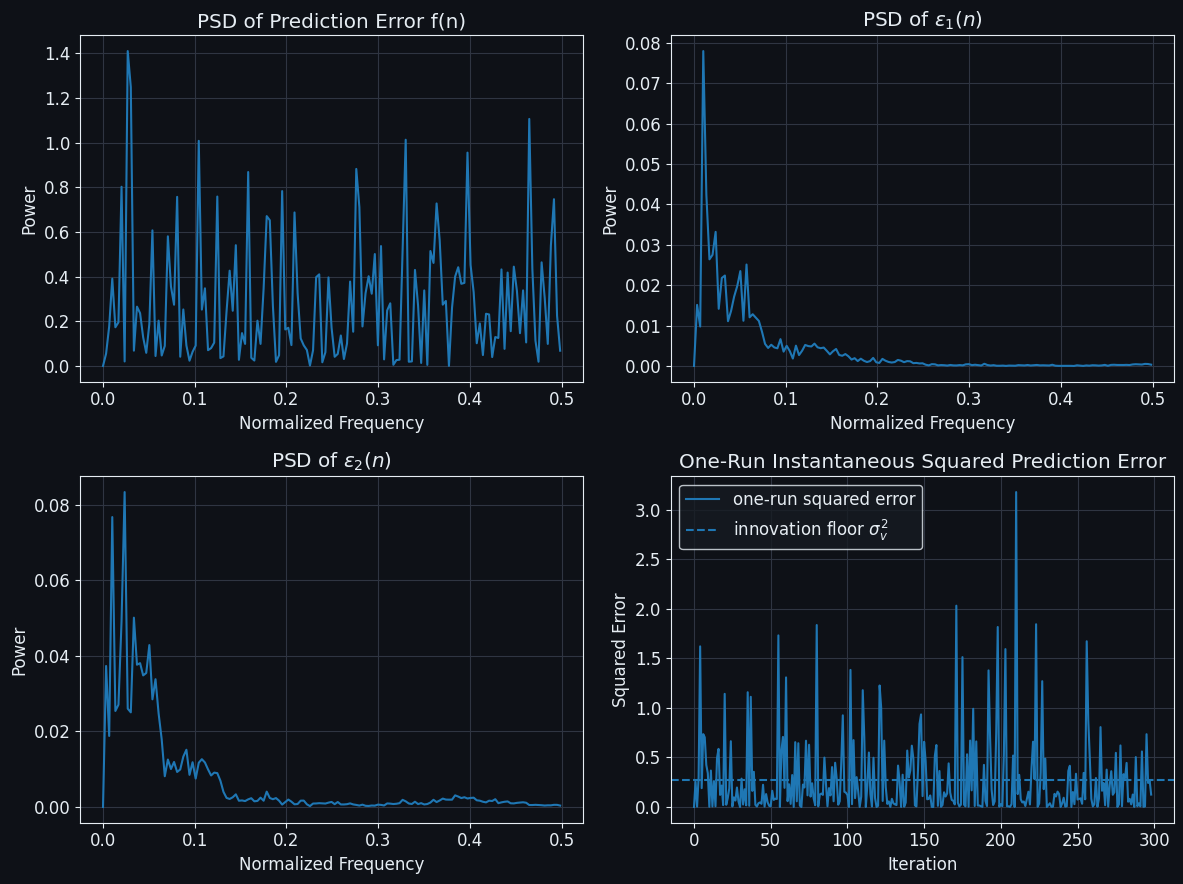

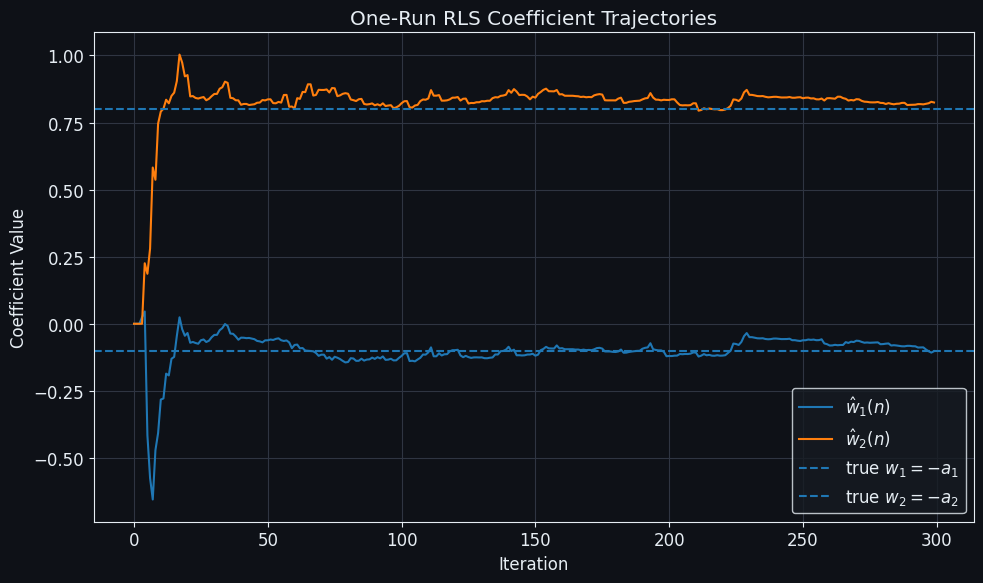

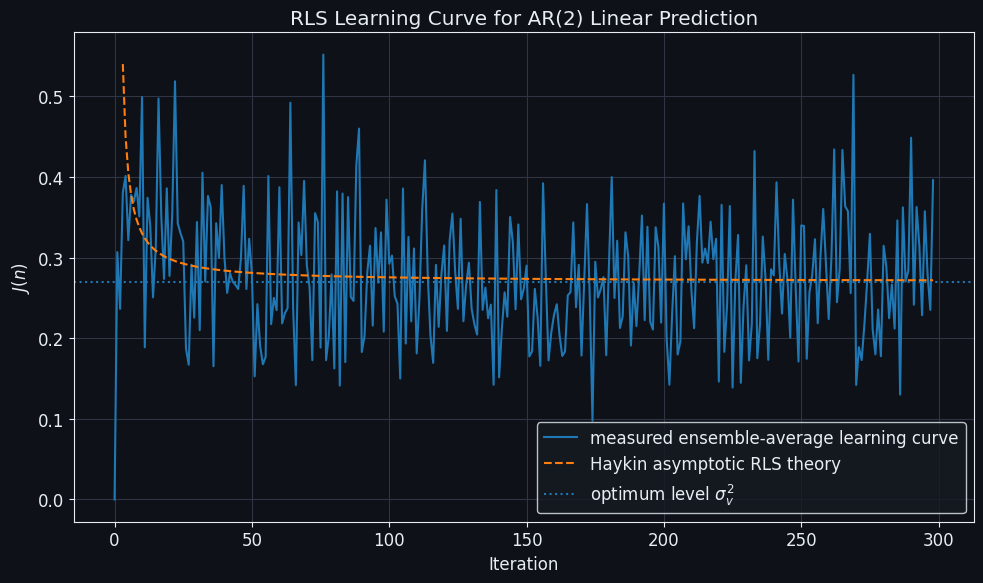

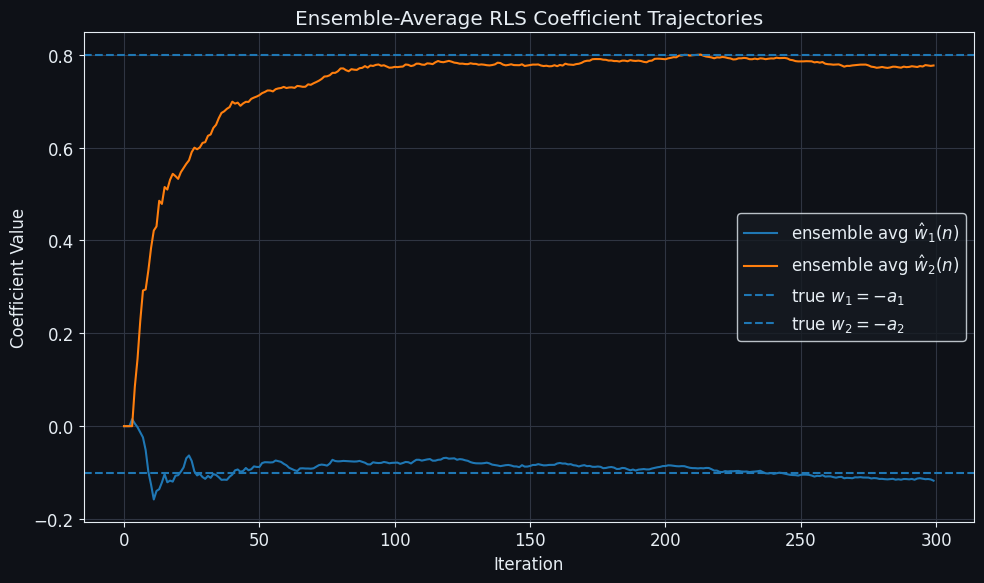

sigma_v^2 = 0.2699999999999998
true w0 = [-0.1  0.8]
final ensemble-average weights = [-0.11736545  0.7768868 ]


In [3]:
res = runAr2RlsExperiment(
  n_samp=300,
  n_runs=25,
  a1=0.1,
  a2=-0.8,
  lam=0.99,
  delta_diniz=1.0,
  seed=30,
  make_plots=True,
)

print("sigma_v^2 =", res["sigma_v2"])
print("true w0 =", res["w0"])
print("final ensemble-average weights =", res["w_hist_avg"][-1])